In [1]:
# ==============================
# 1. Import Required Libraries
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
credit_data = pd.read_csv("C:/Users/vibha/Downloads/credit_card_fraud_10k.csv")

In [3]:
credit_data.head(10)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
5,6,30.53,13,Clothing,0,0,90,2,46,0
6,7,10.77,18,Travel,0,0,48,1,28,0
7,8,362.02,13,Electronics,0,0,68,1,40,0
8,9,165.43,8,Grocery,0,0,80,0,21,0
9,10,221.63,5,Grocery,0,0,59,1,34,0


In [4]:
credit_data.tail(10)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9990,9991,107.74,12,Travel,1,0,26,2,39,0
9991,9992,70.78,18,Clothing,0,0,67,1,40,0
9992,9993,114.66,20,Travel,0,0,64,2,51,0
9993,9994,307.41,0,Grocery,0,1,92,1,26,0
9994,9995,23.96,22,Food,0,0,28,2,19,0
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0
9999,10000,44.06,2,Clothing,0,0,38,0,66,0


In [5]:
print(credit_data.shape)


(10000, 10)


In [6]:
credit_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [7]:
print(credit_data['amount'].value_counts())

amount
3.48      4
6.12      4
14.42     4
150.14    4
0.04      4
         ..
101.17    1
75.37     1
36.74     1
38.07     1
44.06     1
Name: count, Length: 8788, dtype: int64


In [8]:
print(credit_data['amount'].value_counts(normalize=True)*100)

amount
3.48      0.04
6.12      0.04
14.42     0.04
150.14    0.04
0.04      0.04
          ... 
101.17    0.01
75.37     0.01
36.74     0.01
38.07     0.01
44.06     0.01
Name: proportion, Length: 8788, dtype: float64


In [9]:
print(credit_data['transaction_hour'].value_counts())

transaction_hour
14    458
18    439
15    432
17    429
9     426
3     425
1     425
7     425
8     424
21    423
16    421
19    421
13    420
5     419
23    419
20    419
12    417
0     417
22    416
6     413
11    385
2     385
4     384
10    358
Name: count, dtype: int64


In [10]:
print(credit_data['transaction_hour'].value_counts(normalize=True)*100)

transaction_hour
14    4.58
18    4.39
15    4.32
17    4.29
9     4.26
3     4.25
1     4.25
7     4.25
8     4.24
21    4.23
16    4.21
19    4.21
13    4.20
5     4.19
23    4.19
20    4.19
12    4.17
0     4.17
22    4.16
6     4.13
11    3.85
2     3.85
4     3.84
10    3.58
Name: proportion, dtype: float64


In [11]:
print(credit_data['merchant_category'].value_counts())

merchant_category
Food           2093
Clothing       2050
Travel         1990
Grocery        1944
Electronics    1923
Name: count, dtype: int64


In [12]:
print(credit_data['merchant_category'].value_counts(normalize=True)*100)

merchant_category
Food           20.93
Clothing       20.50
Travel         19.90
Grocery        19.44
Electronics    19.23
Name: proportion, dtype: float64


In [13]:
print(credit_data['foreign_transaction'].value_counts())

foreign_transaction
0    9022
1     978
Name: count, dtype: int64


In [14]:
print(credit_data['foreign_transaction'].value_counts(normalize=True)*100)

foreign_transaction
0    90.22
1     9.78
Name: proportion, dtype: float64


In [15]:
print(credit_data['location_mismatch'].value_counts())

location_mismatch
0    9143
1     857
Name: count, dtype: int64


In [16]:
print(credit_data['location_mismatch'].value_counts(normalize=True)*100)

location_mismatch
0    91.43
1     8.57
Name: proportion, dtype: float64


In [17]:
print(credit_data['velocity_last_24h'].value_counts())

velocity_last_24h
1    2694
2    2662
3    1785
0    1378
4     934
5     365
6     131
7      42
8       6
9       3
Name: count, dtype: int64


In [18]:
print(credit_data['velocity_last_24h'].value_counts(normalize=True)*100)

velocity_last_24h
1    26.94
2    26.62
3    17.85
0    13.78
4     9.34
5     3.65
6     1.31
7     0.42
8     0.06
9     0.03
Name: proportion, dtype: float64


In [19]:
print(credit_data['cardholder_age'].value_counts())

cardholder_age
29    215
50    211
65    210
22    209
28    207
62    206
44    206
40    205
31    203
52    201
68    200
49    200
25    199
48    199
32    199
57    199
37    197
64    197
45    197
59    196
60    196
19    196
54    195
53    195
21    195
63    194
34    194
47    193
36    193
18    193
69    192
23    190
33    190
51    188
30    187
42    187
43    187
38    187
46    186
27    186
35    185
24    184
56    184
67    183
39    180
41    176
55    175
61    174
58    174
26    171
20    170
66    164
Name: count, dtype: int64


In [20]:
print(credit_data['cardholder_age'].value_counts(normalize=True)*100)

cardholder_age
29    2.15
50    2.11
65    2.10
22    2.09
28    2.07
62    2.06
44    2.06
40    2.05
31    2.03
52    2.01
68    2.00
49    2.00
25    1.99
48    1.99
32    1.99
57    1.99
37    1.97
64    1.97
45    1.97
59    1.96
60    1.96
19    1.96
54    1.95
53    1.95
21    1.95
63    1.94
34    1.94
47    1.93
36    1.93
18    1.93
69    1.92
23    1.90
33    1.90
51    1.88
30    1.87
42    1.87
43    1.87
38    1.87
46    1.86
27    1.86
35    1.85
24    1.84
56    1.84
67    1.83
39    1.80
41    1.76
55    1.75
61    1.74
58    1.74
26    1.71
20    1.70
66    1.64
Name: proportion, dtype: float64


In [21]:
print(credit_data['is_fraud'].value_counts())

is_fraud
0    9849
1     151
Name: count, dtype: int64


In [22]:
print(credit_data['is_fraud'].value_counts(normalize=True)*100)

is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


In [23]:
credit_data.isnull().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [24]:
credit_data.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


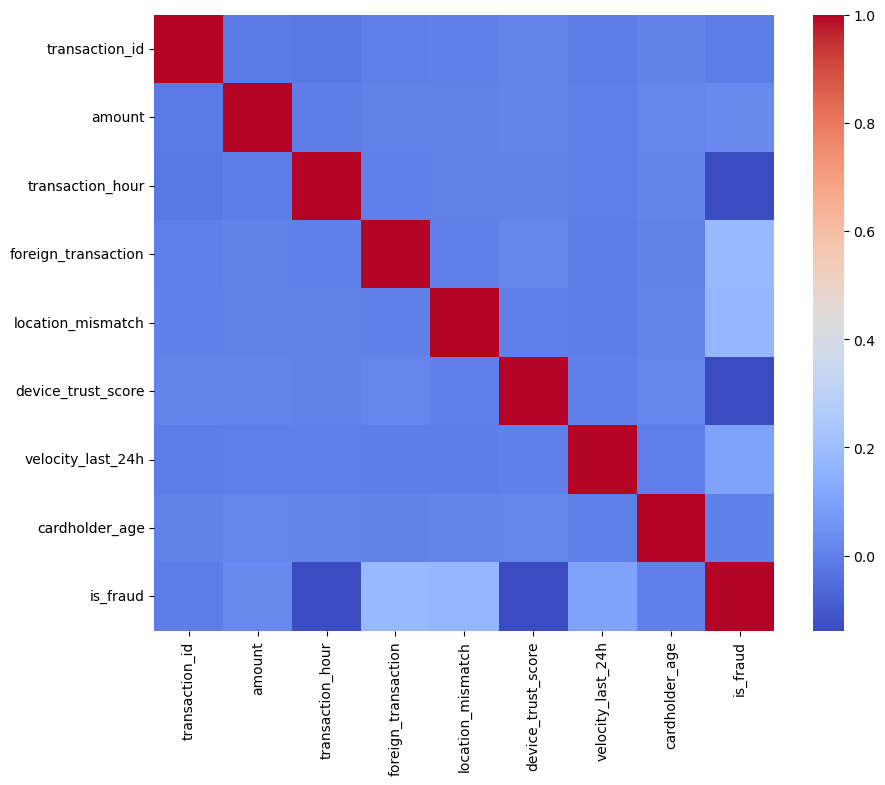

In [25]:
numeric_data = credit_data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr(), cmap="coolwarm")
plt.show()

<B> FEATURE ENGINEERING & PREPROCESSING </B>

In [26]:
credit_data = pd.get_dummies(credit_data, drop_first=True)

<B> FEATURE SCALING </B>

In [30]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = credit_data.drop('is_fraud', axis=1)
y = credit_data['is_fraud']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<B> DIMENSIONALITY REDUCTION </B>

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

<B> KMEANS CLUSTERING </B>

In [34]:
from sklearn.cluster import KMeans
import numpy as np

kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

clusters = kmeans.labels_

credit_data['kmeans_cluster'] = clusters

In [38]:
credit_data['kmeans_cluster']

0       1
1       1
2       0
3       0
4       1
       ..
9995    1
9996    1
9997    1
9998    1
9999    1
Name: kmeans_cluster, Length: 10000, dtype: int32

In [35]:
credit_data['kmeans_cluster'].value_counts()

kmeans_cluster
1    8056
0    1944
Name: count, dtype: int64

In [36]:
pd.crosstab(credit_data['kmeans_cluster'], y)

is_fraud,0,1
kmeans_cluster,,
0,1905,39
1,7944,112


<B> DBSCAN </B>

In [37]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

credit_data['dbscan_cluster'] = db_labels

In [39]:
credit_data['dbscan_cluster'].value_counts()

dbscan_cluster
 4     3415
 5     1636
 2     1618
 0     1574
 10     363
 7      322
 12     180
 1      179
 6      163
 8      152
 13     147
 3      145
-1       38
 14      16
 16      11
 11      10
 15      10
 9        9
 17       8
 18       4
Name: count, dtype: int64

In [40]:
pd.crosstab(credit_data['dbscan_cluster'], y)

is_fraud,0,1
dbscan_cluster,,
-1,25,13
0,1570,4
1,170,9
2,1609,9
3,137,8
4,3405,10
5,1635,1
6,148,15
7,303,19


<B> ISOLATION FOREST </B>

In [42]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    contamination=0.02,   # approx fraud percentage
    random_state=42
)

iso.fit(X_scaled)
iso_preds = iso.predict(X_scaled)

credit_data['iso_pred'] = iso_preds

In [43]:
credit_data['iso_pred'] = credit_data['iso_pred'].map({1:0, -1:1})

In [44]:
credit_data['iso_pred']

0       0
1       1
2       0
3       0
4       0
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: iso_pred, Length: 10000, dtype: int64

In [45]:
from sklearn.metrics import classification_report

print(classification_report(y, credit_data['iso_pred']))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9849
           1       0.31      0.41      0.35       151

    accuracy                           0.98     10000
   macro avg       0.65      0.70      0.67     10000
weighted avg       0.98      0.98      0.98     10000



The model achieves an overall accuracy of 98%, indicating strong general performance. However, class-wise metrics reveal a significant imbalance in prediction quality.

For Class 0, the model performs exceptionally well with 99% precision, recall, and F1-score, correctly identifying the majority class instances (support = 9849).

For Class 1, the performance is considerably weaker, with precision = 0.31, recall = 0.41, and F1-score = 0.35 (support = 151). This suggests that the model struggles to correctly detect the minority class and produces a high number of false positives and false negatives.

The large difference between macro average (F1 = 0.67) and weighted average (F1 = 0.98) further indicates a class imbalance problem, where the model is biased toward the majority class.

<B> EVALUATE ISOLATION FOREST </B>

In [46]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y, credit_data['iso_pred']))
print(classification_report(y, credit_data['iso_pred']))
print("ROC-AUC:", roc_auc_score(y, credit_data['iso_pred']))

[[9711  138]
 [  89   62]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9849
           1       0.31      0.41      0.35       151

    accuracy                           0.98     10000
   macro avg       0.65      0.70      0.67     10000
weighted avg       0.98      0.98      0.98     10000

ROC-AUC: 0.6982922258554504


The model achieves a high **accuracy of 98%**, mainly because it performs extremely well on the majority class (Class 0: F1-score = 0.99). However, performance on the minority class (Class 1) is weak, with **precision = 0.31, recall = 0.41, and F1-score = 0.35**, indicating many false negatives and false positives.

The **ROC-AUC score of 0.69** suggests moderate discrimination ability. Overall, despite high accuracy, the model struggles with class imbalance and does not effectively detect the minority class.


<B> COMPARE ALL MODELS TOGETHER </B>

In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    "KMeans": credit_data['kmeans_cluster'],
    "DBSCAN": credit_data['dbscan_cluster'].apply(lambda x: 1 if x==-1 else 0),
    "IsolationForest": credit_data['iso_pred']
}

for name, preds in models.items():
    print(f"\n{name}")
    print("Precision:", precision_score(y, preds))
    print("Recall:", recall_score(y, preds))
    print("F1:", f1_score(y, preds))


KMeans
Precision: 0.013902681231380337
Recall: 0.7417218543046358
F1: 0.0272937736078957

DBSCAN
Precision: 0.34210526315789475
Recall: 0.08609271523178808
F1: 0.13756613756613756

IsolationForest
Precision: 0.31
Recall: 0.4105960264900662
F1: 0.35327635327635326


Among the three models, **Isolation Forest** performed the best with the highest F1-score (0.35), showing a better balance between precision (0.31) and recall (0.41).

KMeans achieved high recall (0.74) but extremely low precision (0.01), meaning it detected many fraud cases but produced too many false positives. DBSCAN had moderate precision (0.34) but very low recall (0.08), missing most fraud cases.

Overall, Isolation Forest is the most suitable model among the three for fraud detection in this case.


<B> improve the best model: </B>

In [49]:
iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    max_samples='auto',
    random_state=42
)

In [51]:
iso

,n_estimators,200
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False
